In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import json


## SF

In [3]:
occupancy = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.88310, 0.40861, 0.24189, 0.24189, 0.24189, 0.24189, 0.24189, 0.24189, 0.24189, 0.29498, 0.55310, 0.89693, 0.89693, 0.89693, 1.0, 1.0, 1.0]
lighting = [0.0625, 0.0625, 0.0625, 0.0625, 0.1875, 0.390625, 0.4375, 0.390625, 0.171875, 0.1171875, 0.1171875, 0.1171875, 0.1171875, 0.1171875, 0.1171875, 0.203125, 0.4375, 0.609375, 0.8203125, 0.984375, 1, 0.6875, 0.3828125, 0.15625]

# heating setpoint 22.2222222222223
# cooling setpoint23.888888888889

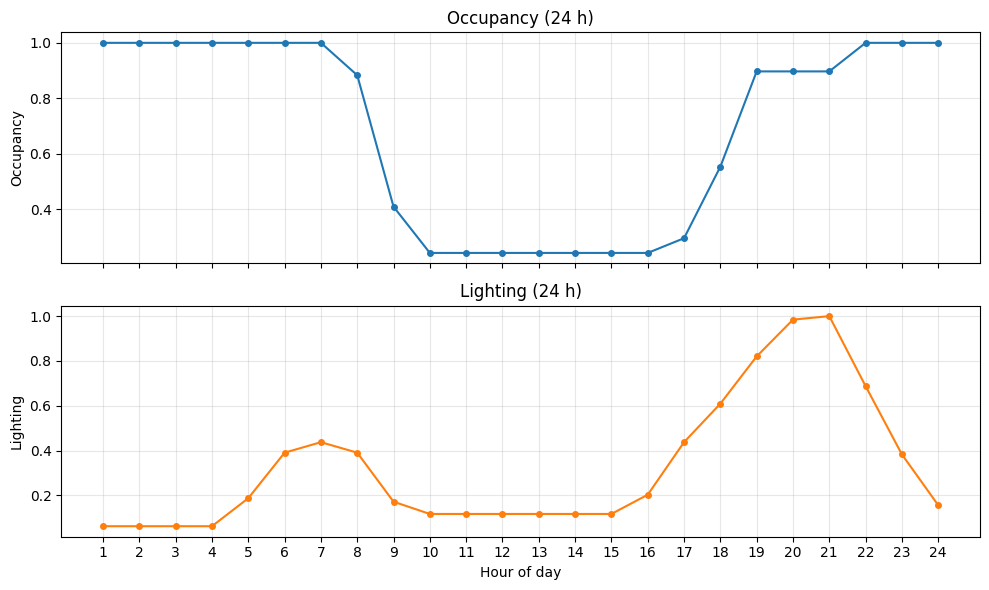

In [29]:
hours = np.arange(1, 25)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(hours, occupancy, marker="o", markersize=4)
ax1.set_ylabel("Occupancy")
ax1.set_title("Occupancy (24 h)")
ax1.grid(True, alpha=0.3)
ax2.plot(hours, lighting, marker="o", markersize=4, color="C1")
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Lighting")
ax2.set_title("Lighting (24 h)")
ax2.set_xticks(hours)
ax2.set_xticklabels(hours)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ESO file path (EnergyPlus output)
ESO_PATH = "files/US+SF+CZ4A+hp+slab+IECC_2024.eso"

# Variable IDs from data dictionary (lines 8-17): first number on each line
ESO_VAR_IDS = [129, 203, 241, 279, 317, 355, 393, 431, 1227, 1276]
ESO_VAR_NAMES = [
    "DISHWASHER1", "REFRIGERATOR1", "CLOTHESWASHER1", "ELECTRIC_DRYER1",
    "ELECTRIC_RANGE1", "TELEVISION1", "ELECTRIC_MELS1", "IECC_ADJ1",
    "DHW_Water_m3", "DHW_MainsWater_m3"
]
ESO_VAR_ID_TO_NAME = dict(zip(ESO_VAR_IDS, ESO_VAR_NAMES))

In [5]:
# Parse ESO: after "End of Data Dictionary", each data line is "id,value"
# We collect all values per id (design days + run period), no truncation.
with open(ESO_PATH) as f:
    lines = f.readlines()

# Skip to data (after "End of Data Dictionary")
i = 0
while i < len(lines) and "End of Data Dictionary" not in lines[i]:
    i += 1
i += 1  # first line after End of Data Dictionary

# Collect all values per variable (in file order)
values_by_id = {vid: [] for vid in ESO_VAR_IDS}
while i < len(lines):
    line = lines[i].strip()
    # Data lines: "id,value" where id is one of ESO_VAR_IDS
    for vid in ESO_VAR_IDS:
        prefix = f"{vid},"
        if line.startswith(prefix):
            value = float(line[len(prefix):].strip())
            values_by_id[vid].append(value)
            break
    i += 1

# Full arrays (all hours: design days + run period)
eso_arrays = {}
for vid in ESO_VAR_IDS:
    arr = np.array(values_by_id[vid])
    eso_arrays[vid] = arr
    eso_arrays[ESO_VAR_ID_TO_NAME[vid]] = arr  # also key by name

# DataFrame with all rows and one column per variable
eso_df = pd.DataFrame({ESO_VAR_ID_TO_NAME[vid]: eso_arrays[vid] for vid in ESO_VAR_IDS})
print(eso_df.shape)  # (total_hours, 10)
eso_df

(8808, 10)


,DISHWASHER1,REFRIGERATOR1,CLOTHESWASHER1,ELECTRIC_DRYER1,ELECTRIC_RANGE1,TELEVISION1,ELECTRIC_MELS1,IECC_ADJ1,DHW_Water_m3,DHW_MainsWater_m3
0,5.139874,67.510549,1.378866,25.983483,11.702577,0.0,344.729004,207.061370,0.001841,0.001841
1,2.283645,66.050310,1.102798,15.590090,11.702577,0.0,317.404608,190.648979,0.000993,0.000993
2,1.711059,64.607052,0.550661,10.393393,5.843012,0.0,313.724554,188.438556,0.000635,0.000635
3,1.141822,62.688366,0.550661,5.196697,5.843012,0.0,309.308490,185.786049,0.000718,0.000718
4,1.141822,61.720534,1.102798,10.393393,11.702577,0.0,297.624320,178.767956,0.001466,0.001466
...,...,...,...,...,...,...,...,...,...,...
8803,37.141034,81.977095,7.173353,133.040680,99.496735,0.0,548.603964,329.518801,0.009739,0.009739
8804,30.283403,79.566004,7.173353,137.187539,58.529438,0.0,567.464238,340.847218,0.008955,0.008955
8805,22.283951,78.105765,6.897284,142.384235,40.967296,0.0,554.216045,332.889696,0.007848,0.007848
8806,14.853735,74.743822,4.690212,114.327323,25.739049,0.0,479.602962,288.073371,0.005893,0.005893


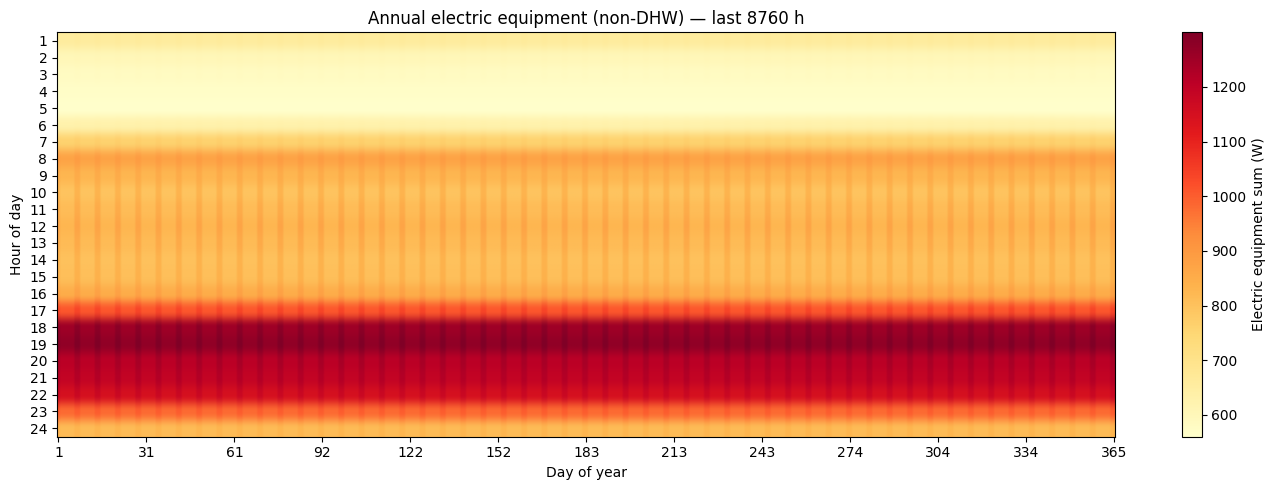

In [15]:
# Last 8760 hours: sum of non-DHW columns, reshape to (24, 365) for heatmap
RUN_HOURS = 8760
non_dhw_cols = ["DISHWASHER1", "REFRIGERATOR1", "CLOTHESWASHER1", "ELECTRIC_DRYER1",
                "ELECTRIC_RANGE1", "TELEVISION1", "ELECTRIC_MELS1", "IECC_ADJ1"]
last_8760 = eso_df[non_dhw_cols].tail(RUN_HOURS)
hourly_sum = last_8760.sum(axis=1).values  # shape (8760,)
# Reshape: row = hour of day (0..23), col = day of year (0..364)
heatmap_data = hourly_sum.reshape(365, 24).T  # (24, 365)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, aspect="auto", cmap="YlOrRd")
ax.set_yticks(np.arange(24))
ax.set_yticklabels(np.arange(1, 25))
ax.set_ylabel("Hour of day")
ax.set_xticks(np.linspace(0, 364, 13))
ax.set_xticklabels(np.linspace(1, 365, 13, dtype=int))
ax.set_xlabel("Day of year")
plt.colorbar(im, ax=ax, label="Electric equipment sum (W)")
plt.title("Annual electric equipment (non-DHW) — last 8760 h")
plt.tight_layout()
plt.show()

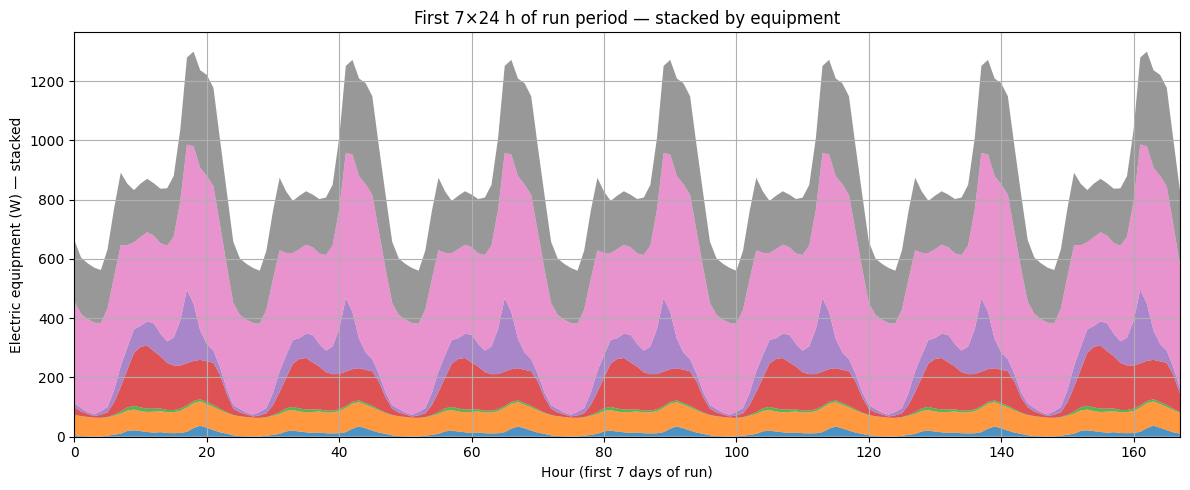

In [ ]:
# First 7×24 = 168 hours of RUN PERIOD (last 8760), so we see real first week of year
n_week = 7 * 24  # 168
run_period = eso_df[non_dhw_cols].tail(RUN_HOURS)  # last 8760 = annual run
week_df = run_period.head(n_week)                   # first week of run
x = np.arange(n_week)

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(x, *[week_df[c].values for c in non_dhw_cols], labels=non_dhw_cols, alpha=0.8)
ax.set_xlim(0, n_week - 1)
ax.set_xlabel("Hour (first 7 days of run)")
ax.set_ylabel("Electric equipment (W) — stacked")
ax.set_title("First 7×24 h of run period — stacked by equipment")
ax.grid(True)
#ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

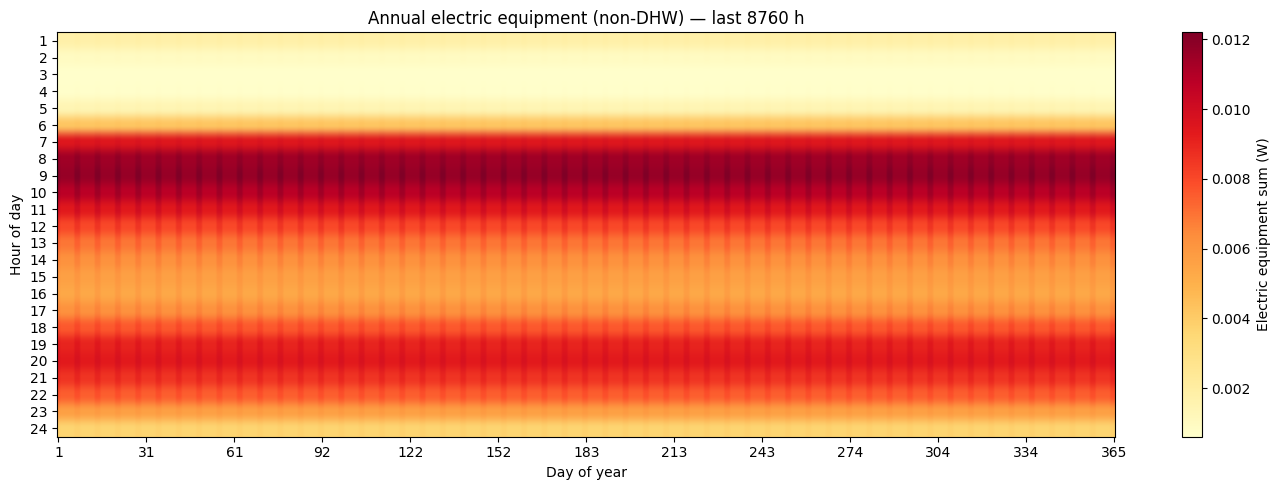

In [34]:
# Last 8760 hours: sum of non-DHW columns, reshape to (24, 365) for heatmap
RUN_HOURS = 8760
dhw_col_1 = ["DHW_Water_m3"]
last_8760 = eso_df[dhw_col_1].tail(RUN_HOURS)
# Reshape: row = hour of day (0..23), col = day of year (0..364)
heatmap_data = last_8760.values.reshape(365, 24).T  # (24, 365)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, aspect="auto", cmap="YlOrRd")
ax.set_yticks(np.arange(24))
ax.set_yticklabels(np.arange(1, 25))
ax.set_ylabel("Hour of day")
ax.set_xticks(np.linspace(0, 364, 13))
ax.set_xticklabels(np.linspace(1, 365, 13, dtype=int))
ax.set_xlabel("Day of year")
plt.colorbar(im, ax=ax, label="Electric equipment sum (W)")
plt.title("Annual electric equipment (non-DHW) — last 8760 h")
plt.tight_layout()
plt.show()

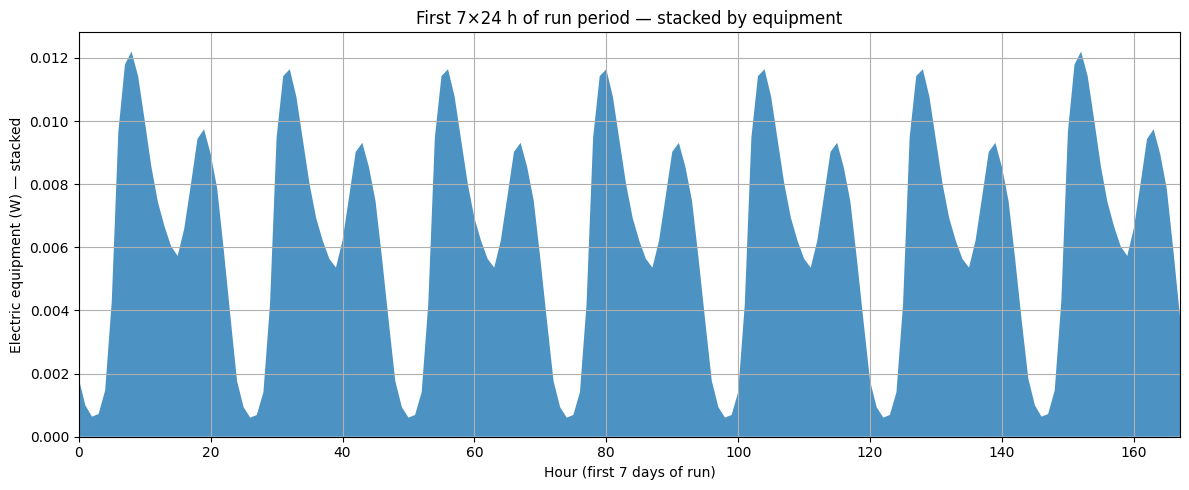

In [36]:
n_week = 7 * 24  # 168
run_period = eso_df[dhw_col_1].tail(RUN_HOURS)  # last 8760 = annual run
week_df = run_period.head(n_week)                   # first week of run
x = np.arange(n_week)

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(x, *[week_df[c].values for c in dhw_col_1], labels=dhw_col_1, alpha=0.8)
ax.set_xlim(0, n_week - 1)
ax.set_xlabel("Hour (first 7 days of run)")
ax.set_ylabel("Electric equipment (W) — stacked")
ax.set_title("First 7×24 h of run period — stacked by equipment")
ax.grid(True)
#ax.legend(loc="lower center")
plt.tight_layout()
plt.show()